# 05 · Autoencoders and the latent space

An **autoencoder** learns to squeeze a curve through a narrow **bottleneck**
and rebuild it. The bottleneck is a **latent space**: a compact, learned
coordinate system where *similar curves sit together*. It is the concept behind
learning representations of mechanical responses.

You will learn:
1. how to train a small autoencoder on indentation curves,
2. how to read the **2-D latent space** and cluster in it,
3. how **reconstruction error** flags **anomalies** (e.g. pop-ins / bad indents).

> We train the autoencoder only to *reconstruct*, then cluster the latent space
> as a separate step — a clean, transparent baseline.

In [1]:
# --- setup: find the repo (auto-clone on Colab), load helpers, set plot style ---
import os, sys, subprocess
def _find_src():
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None
if _find_src() is None:                    # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)
sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import mecanano_ml as mm
mm.set_style()
print("helpers loaded from:", mm.__file__)

helpers loaded from: /tmp/stage/repo/src/mecanano_ml/__init__.py


In [2]:
import torch, torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
torch.manual_seed(0); np.random.seed(0)

## 1 · Curves in, standardised
We use the hardness–depth curve of each AFM indent (64 points), median-imputed and z-scored per depth.

In [3]:
afm = mm.load_afm_grid()
C = afm["H_curve"].copy()
keep = np.isfinite(C).mean(0) > 0.5
C = SimpleImputer(strategy="median").fit_transform(C[:, keep])
scaler = StandardScaler(); Cs = scaler.fit_transform(C)
Xt = torch.tensor(Cs, dtype=torch.float32)
print("curve matrix:", Cs.shape)

curve matrix: (828, 60)


## 2 · A tiny autoencoder
`64 → 16 → 2 → 16 → 64`. The 2-D middle layer is the latent space we will visualise.

final reconstruction MSE: 0.0572


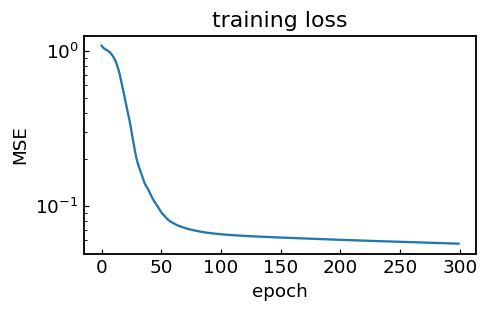

In [4]:
d = Cs.shape[1]
class AE(nn.Module):
    def __init__(self, d, latent=2):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d,16), nn.ReLU(), nn.Linear(16,latent))
        self.dec = nn.Sequential(nn.Linear(latent,16), nn.ReLU(), nn.Linear(16,d))
    def forward(self,x):
        z = self.enc(x); return self.dec(z), z
ae = AE(d); opt = torch.optim.Adam(ae.parameters(), 5e-3); lossf = nn.MSELoss()
losses = []
for epoch in range(300):
    opt.zero_grad(); xr,_ = ae(Xt); loss = lossf(xr, Xt); loss.backward(); opt.step()
    losses.append(loss.item())
print("final reconstruction MSE:", round(losses[-1], 4))
fig, ax = plt.subplots(figsize=(4.6,3)); ax.plot(losses); ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
ax.set_yscale("log"); ax.set_title("training loss"); fig.tight_layout()

## 3 · The latent space
Each curve is now a point in 2-D. Colour by hardness: the latent axes have organised the curves by their mechanical response, with no labels given.

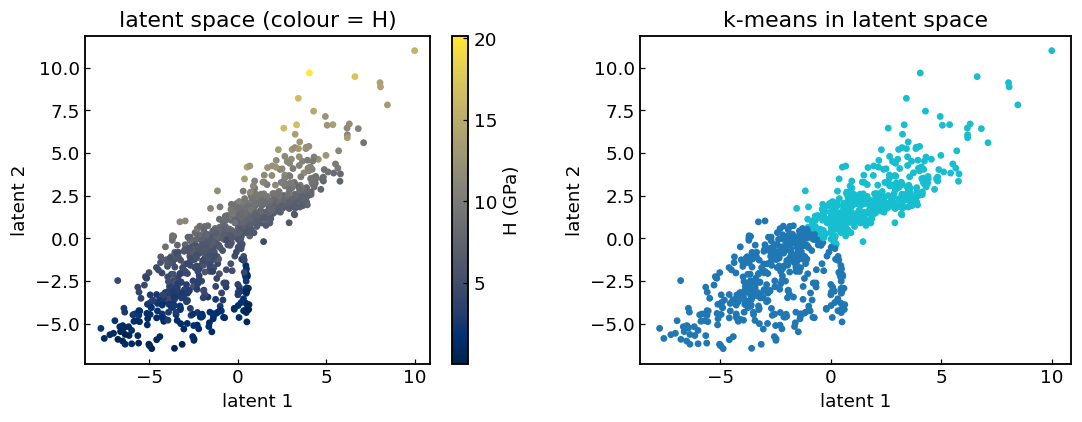

In [5]:
ae.eval()
with torch.no_grad():
    recon, Z = ae(Xt)
Z = Z.numpy()
kl = KMeans(2, n_init=10, random_state=0).fit_predict(Z)     # cluster the latent space
fig, ax = plt.subplots(1,2, figsize=(10,4))
s0=ax[0].scatter(Z[:,0], Z[:,1], c=afm["H"], s=12, cmap="cividis")
ax[0].set_xlabel("latent 1"); ax[0].set_ylabel("latent 2"); ax[0].set_title("latent space (colour = H)")
plt.colorbar(s0, ax=ax[0], label="H (GPa)")
ax[1].scatter(Z[:,0], Z[:,1], c=kl, s=12, cmap="tab10")
ax[1].set_xlabel("latent 1"); ax[1].set_ylabel("latent 2"); ax[1].set_title("k-means in latent space")
fig.tight_layout()

## 4 · Reconstruction error = anomaly score
Curves the autoencoder rebuilds poorly are unusual — pop-ins, cracked indents, surface artefacts. This is a label-free way to **triage** a big map.

flagged anomalies: 25


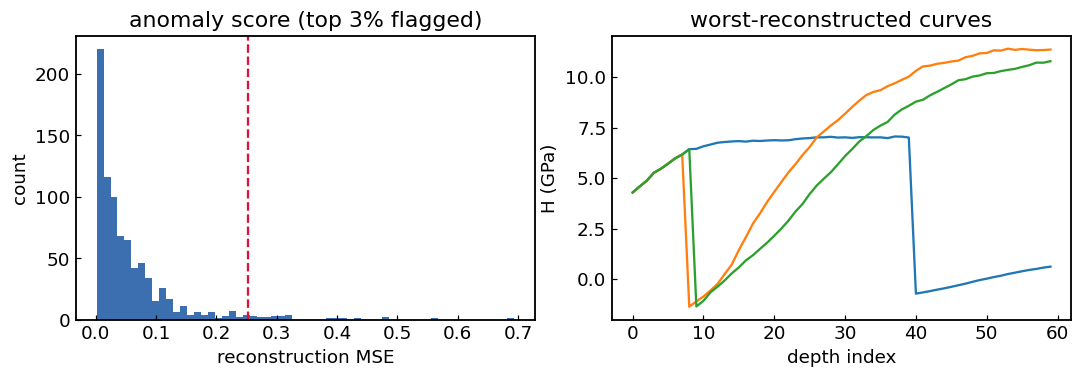

In [6]:
err = ((recon - Xt)**2).mean(1).numpy()
thr = np.quantile(err, 0.97)
fig, ax = plt.subplots(1,2, figsize=(10,3.6))
ax[0].hist(err, bins=60, color="#3b6fb0"); ax[0].axvline(thr, c="crimson", ls="--")
ax[0].set_xlabel("reconstruction MSE"); ax[0].set_ylabel("count"); ax[0].set_title("anomaly score (top 3% flagged)")
worst = np.argsort(err)[-3:]
for i in worst:
    ax[1].plot(scaler.inverse_transform(Cs[i][None])[0], lw=1.5)
ax[1].set_title("worst-reconstructed curves"); ax[1].set_xlabel("depth index"); ax[1].set_ylabel("H (GPa)")
fig.tight_layout()
print("flagged anomalies:", int((err>thr).sum()))

## Recap
- An **autoencoder** learns a compact **latent space** where similar curves
  cluster together — a data-driven representation of mechanical response.
- Clustering that latent space is a transparent baseline for grouping curves.
- **Reconstruction error** is a free **anomaly detector** for flagging bad or
  unusual indents before analysis.

Joint representation-and-clustering methods exist and go further, but a plain
autoencoder already gives you the intuition and a useful tool.

**Next:** the refreshed classics — `10_cnn_mnist`, `11_popin_detection`, …